# Test just the OCR part (CPU + llama.cpp, same as the Docker deployment)

This mirrors the `llama-server` + PaddleOCR-VL setup from `docker-compose.yml` -- alignment (OpenCV) plus the actual OCR call, timed, so you can see real speed/output on CPU before deploying to Hostinger. It skips the FastAPI wrapper, master-data validation, and field parsing -- just the OCR itself.

**Runtime:** CPU is fine and is the point (testing the same CPU path as your VPS). If you want to sanity-check GPU-path speed for comparison, you *can* pick a GPU runtime here too, but that's a different test from what your Hostinger box will actually run.

Honesty note: the llama.cpp build step below was validated for correctness (clone + cmake configure + partial compile, including confirming native PaddleOCR architecture support compiles cleanly) but not run to completion in the environment that built this notebook, due to sandbox constraints (1 CPU core, tool time limits) unrelated to Colab itself. Colab's cores should complete it in a few minutes -- if the build step errors, paste the output back and we'll debug it directly.

## 1. Build llama.cpp
A few minutes -- this compiles from source since prebuilt Linux binaries aren't consistently published for every release.

In [1]:
!apt-get update -qq && apt-get install -y -qq cmake build-essential > /dev/null
!git clone --depth 1 https://github.com/ggml-org/llama.cpp.git
%cd llama.cpp
!cmake -B build
!cmake --build build -j$(nproc) --target llama-server
%cd ..

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
fatal: destination path 'llama.cpp' already exists and is not an empty directory.
/content/llama.cpp
CMAKE_BUILD_TYPE=Release
-- Warning: ccache not found - consider installing it for faster compilation or disable this warning with GGML_CCACHE=OFF
-- CMAKE_SYSTEM_PROCESSOR: x86_64
-- GGML_SYSTEM_ARCH: x86
-- Including CPU backend
-- x86 detected
-- Adding CPU backend variant ggml-cpu: -march=native 
-- ggml version: 0.16.0
-- ggml commit:  f955e39
-- OpenSSL found: 3.0.2
-- Generating embedded license file for target: llama-app
-- Configuring done (0.4s)
-- Generating done (0.4s)
-- Build files have been written to: /content/llama.cpp/build
[  1%] Built target llama-common-base
[  1%] Built target cpp-httplib
[  5%] Built target ggml-base
[  5%] Built target llama-ui-embed
[  5%] Provisioning UI asse

In [2]:
# Sanity check: confirm the binary actually built
import os
server_bin = "llama.cpp/build/bin/llama-server"
assert os.path.exists(server_bin), f"Build did not produce {server_bin} -- check the cell above for errors"
print("llama-server built successfully:", server_bin)

llama-server built successfully: llama.cpp/build/bin/llama-server


## 2. Download the PaddleOCR-VL-1.6 GGUF weights (~1.8GB, one time)

In [3]:
!mkdir -p models
!curl -L -o models/PaddleOCR-VL-1.6-GGUF.gguf \
  "https://huggingface.co/PaddlePaddle/PaddleOCR-VL-1.6-GGUF/resolve/main/PaddleOCR-VL-1.6-GGUF.gguf"
!curl -L -o models/PaddleOCR-VL-1.6-GGUF-mmproj.gguf \
  "https://huggingface.co/PaddlePaddle/PaddleOCR-VL-1.6-GGUF/resolve/main/PaddleOCR-VL-1.6-GGUF-mmproj.gguf"
!ls -lh models/

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  1028  100  1028    0     0   8270      0 --:--:-- --:--:-- --:--:--  8290
100  892M  100  892M    0     0   242M      0  0:00:03  0:00:03 --:--:--  266M
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  1042  100  1042    0     0   9428      0 --:--:-- --:--:-- --:--:--  9472
100  840M  100  840M    0     0   225M      0  0:00:03  0:00:03 --:--:--  236M
total 1.7G
-rw-r--r-- 1 root root 893M Jul 15 10:53 PaddleOCR-VL-1.6-GGUF.gguf
-rw-r--r-- 1 root root 841M Jul 15 10:53 PaddleOCR-VL-1.6-GGUF-mmproj.gguf


## 3. Start llama-server in the background
Same flags as `docker-compose.yml`, threads adjusted to whatever Colab actually gives this runtime (check with `nproc` -- Colab's free tier is commonly 2 vCPUs, sometimes more).

In [4]:
import subprocess, time, os, multiprocessing

n_threads = max(multiprocessing.cpu_count() - 1, 1)  # leave 1 core for the Python side, same logic as the Docker split
print(f"Detected {multiprocessing.cpu_count()} CPUs -- giving llama-server {n_threads} thread(s)")

server_log = open("/content/llama_server.log", "w")
server_proc = subprocess.Popen([
    "llama.cpp/build/bin/llama-server",
    "--model", "models/PaddleOCR-VL-1.6-GGUF.gguf",
    "--mmproj", "models/PaddleOCR-VL-1.6-GGUF-mmproj.gguf",
    "--host", "127.0.0.1",
    "--port", "8081",
    "--threads", str(n_threads),
    "--ctx-size", "4096",
    "--temp", "0",
    "--mlock",
], stdout=server_log, stderr=subprocess.STDOUT)

print(f"llama-server starting (PID {server_proc.pid}), logging to /content/llama_server.log ...")

Detected 2 CPUs -- giving llama-server 1 thread(s)
llama-server starting (PID 10854), logging to /content/llama_server.log ...


In [5]:
# Wait for it to actually be ready -- model loading takes a bit
import urllib.request, urllib.error

for attempt in range(60):
    try:
        with urllib.request.urlopen("http://127.0.0.1:8081/health", timeout=3) as resp:
            if resp.status == 200:
                print("llama-server is ready.")
                break
    except (urllib.error.URLError, TimeoutError):
        pass
    if server_proc.poll() is not None:
        print("llama-server process exited early -- check the log:")
        print(open("/content/llama_server.log").read()[-2000:])
        break
    time.sleep(5)
else:
    print("Timed out waiting for llama-server. Log tail:")
    print(open("/content/llama_server.log").read()[-2000:])

llama-server is ready.


## 4. Install PaddleOCR-VL + the alignment dependencies

In [6]:
!pip install -q paddlepaddle==3.2.1 "paddleocr[doc-parser]>=3.6.0" opencv-python-headless pillow numpy

## 5. Upload `aligner.py` and a test slip photo
`aligner.py` is the same file from the delivered system -- upload it here so this test uses identical alignment logic to production, not a reimplementation.

In [7]:
from google.colab import files
print("Select aligner.py:")
files.upload()
print("\nSelect a slip photo to test:")
photo_upload = files.upload()
photo_path = list(photo_upload.keys())[0]
print(f"Using: {photo_path}")

Select aligner.py:


Saving aligner.py to aligner (1).py

Select a slip photo to test:


Saving PHOTO-2026-07-09-13-33-24.jpg to PHOTO-2026-07-09-13-33-24 (1).jpg
Using: PHOTO-2026-07-09-13-33-24 (1).jpg


## 6. Align the photo

Alignment status: ok (method=border_box)


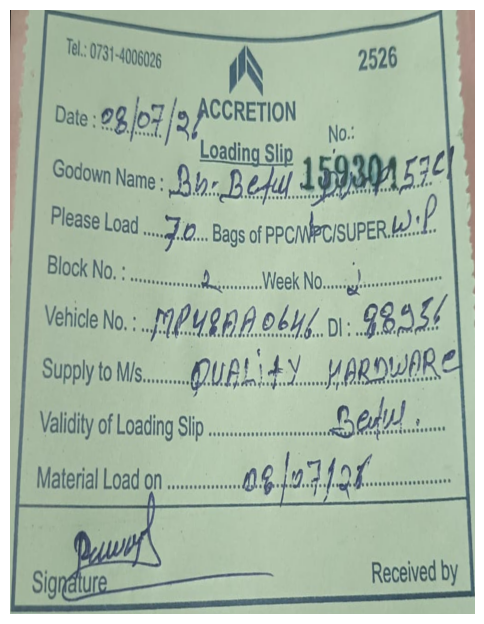

In [8]:
from aligner import align_slip
import cv2

warped, status = align_slip(photo_path)
print("Alignment status:", status)
assert warped is not None, "Alignment failed -- try a different photo"
cv2.imwrite("aligned.jpg", warped)

import matplotlib.pyplot as plt
plt.figure(figsize=(6, 8))
plt.imshow(cv2.cvtColor(warped, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

## 7. Run the actual OCR test -- timed
Same `vl_rec_backend="llama-cpp-server"` configuration as `ocr_engine.py` in the Docker deployment.

In [10]:
from paddleocr import PaddleOCRVL
import time

# Only initialize the pipeline if it hasn't been initialized yet
# This prevents RuntimeError: PDX has already been initialized. Reinitialization is not supported.
if 'pipeline' not in locals() or pipeline is None:
    print("Loading PaddleOCRVL pipeline (layout detection model, CPU)...")
    t0 = time.time()
    pipeline = PaddleOCRVL(
        pipeline_version="v1.6",
        vl_rec_backend="llama-cpp-server",
        vl_rec_server_url="http://127.0.0.1:8081/v1",
        use_doc_orientation_classify=False,
        use_doc_unwarping=False,
        # Removed 'use_textline_orientation=False' as it's an unknown argument
    )
    print(f"Pipeline init: {time.time() - t0:.1f}s")
else:
    print("PaddleOCRVL pipeline already initialized.")

Loading PaddleOCRVL pipeline (layout detection model, CPU)...


/usr/local/lib/python3.12/dist-packages/paddle/utils/cpp_extension/extension_utils.py:718: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Creating model: ('PP-DocLayoutV3', None, None)
Checking connectivity to the model hosters, this may take a while. To bypass this check, set `PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK` to `True`.
Using official model (PP-DocLayoutV3), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-DocLayoutV3`.


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Creating model: ('PaddleOCR-VL-1.6-0.9B', None, None)


Pipeline init: 13.5s


In [13]:
import glob, tempfile

t0 = time.time()
output = pipeline.predict("aligned.jpg")

with tempfile.TemporaryDirectory() as tmp_dir:
    for res in output:
        res.save_to_markdown(save_path=tmp_dir)
    md_files = glob.glob(f"{tmp_dir}/*.md")
    raw_text = "\n".join(open(f, encoding="utf-8").read() for f in md_files)

elapsed = time.time() - t0
print(f"\n{'='*60}\nOCR TIME: {elapsed:.2f} seconds\n{'='*60}\n")
print(raw_text)

/usr/local/lib/python3.12/dist-packages/paddlex/inference/models/doc_vlm/predictor.py:545: UserWarning: 'llama-cpp-server' does not support `min_pixels`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/paddlex/inference/models/doc_vlm/predictor.py:558: UserWarning: 'llama-cpp-server' does not support `max_pixels`.
  warnings.warn(



OCR TIME: 17.79 seconds

Tel.: 0731-4006026

2526

Date: 08/07/2023 ACCRETION

Godown Name: Bbr. Befu 15930157C

Please Load .....70 Bags of PPC/NPC/SUPER.

Block No.: ___ Week No.....

Vehicle No.: MP48AA0646 DI: 98936

Supply to M/s.....QUALITY HARDWARE

Validity of Loading Slip.....Bedul..

Material Load on .....08/07/20


## 8. Run it a second time
First call includes some one-off warm-up cost inside llama-server (KV cache allocation, etc.) -- a second call on a different photo gives a more representative per-slip time for what production will actually see.

In [12]:
print("Select another slip photo:")
photo_upload_2 = files.upload()
photo_path_2 = list(photo_upload_2.keys())[0]

t0 = time.time()
warped2, status2 = align_slip(photo_path_2)
print("Alignment status:", status2)
cv2.imwrite("aligned2.jpg", warped2)
align_time = time.time() - t0

t0 = time.time()
output2 = pipeline.predict("aligned2.jpg")
with tempfile.TemporaryDirectory() as tmp_dir:
    for res in output2:
        res.save_to_markdown(save_path=tmp_dir)
    md_files = glob.glob(f"{tmp_dir}/*.md")
    raw_text_2 = "\n".join(open(f, encoding="utf-8").read() for f in md_files)
ocr_time = time.time() - t0

print(f"\nAlignment: {align_time:.2f}s | OCR: {ocr_time:.2f}s | Total: {align_time + ocr_time:.2f}s\n")
print(raw_text_2)

Select another slip photo:


Saving PHOTO-2026-07-08-13-55-06.jpg to PHOTO-2026-07-08-13-55-06.jpg
Alignment status: ok (method=border_box)


/usr/local/lib/python3.12/dist-packages/paddlex/inference/models/doc_vlm/predictor.py:545: UserWarning: 'llama-cpp-server' does not support `min_pixels`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/paddlex/inference/models/doc_vlm/predictor.py:558: UserWarning: 'llama-cpp-server' does not support `max_pixels`.
  warnings.warn(



Alignment: 0.05s | OCR: 268.60s | Total: 268.64s

Tel.: 0731-4006026

14 2526

Date: 8.17.26 ACCRETION Loading Slip 178115

Godown Name: Harsi Pump

Please Load ..... 100... Bags of PPC/NPC/SUPER. PPC

Block No.: 04 Week No.

Vehicle No.: MPQ5AJ3109.....DI:8818...

Supply to M/s... Patel Sales,

Validity of Loading Slip (Sontalai)

Material Load on Palgoods


## Cleanup
Stop the background server when you're done testing (or just let the Colab runtime disconnect/reset, which kills it automatically).

In [ ]:
server_proc.terminate()
print("llama-server stopped.")